# 03 — Visualize the Wisdom LM

Two views into what the trained transformer learned:

1. **Character embedding space** — PCA projection of the 67-character embedding matrix.
2. **Attention heatmaps** — per-layer, per-head attention weights for a given phrase, showing what each position attends to when predicting the next character.

In [6]:
import os
os.chdir('c:\\Users\\hmhol\\Python scripts\\nlp\\wisdom_small_lm')

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.decomposition import PCA

from tokenizer import load_vocab
from model import build_model

print(f"Working directory: {os.getcwd()}")

Working directory: c:\Users\hmhol\Python scripts\nlp\wisdom_small_lm


## Setup — Load vocab and model

In [7]:
char_to_idx, idx_to_char = load_vocab()
VOCAB_SIZE  = len(char_to_idx)
CONTEXT_LEN = 128
DEVICE      = torch.device("cpu")

model = build_model(
    arch        = "transformer",
    vocab_size  = VOCAB_SIZE,
    embed_dim   = 64,
    n_heads     = 4,
    n_layers    = 2,
    ff_dim      = 256,
    context_len = CONTEXT_LEN,
    dropout     = 0.1,
).to(DEVICE)

ckpt = torch.load("model_transformer_ckpt_05.pt", map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Loaded model — epoch {ckpt['epoch']}, val loss {ckpt['val_losses'][-1]:.4f}")

Loaded model — epoch 5, val loss 1.3253


## 1 — Character Embedding Space

The 67-character embedding matrix lives in 64 dimensions. PCA projects it down to 2D so we can see which characters ended up near each other after training.

Expect to see loose clusters by character type — the model learned these groupings purely from predicting the next character, with no explicit labels.

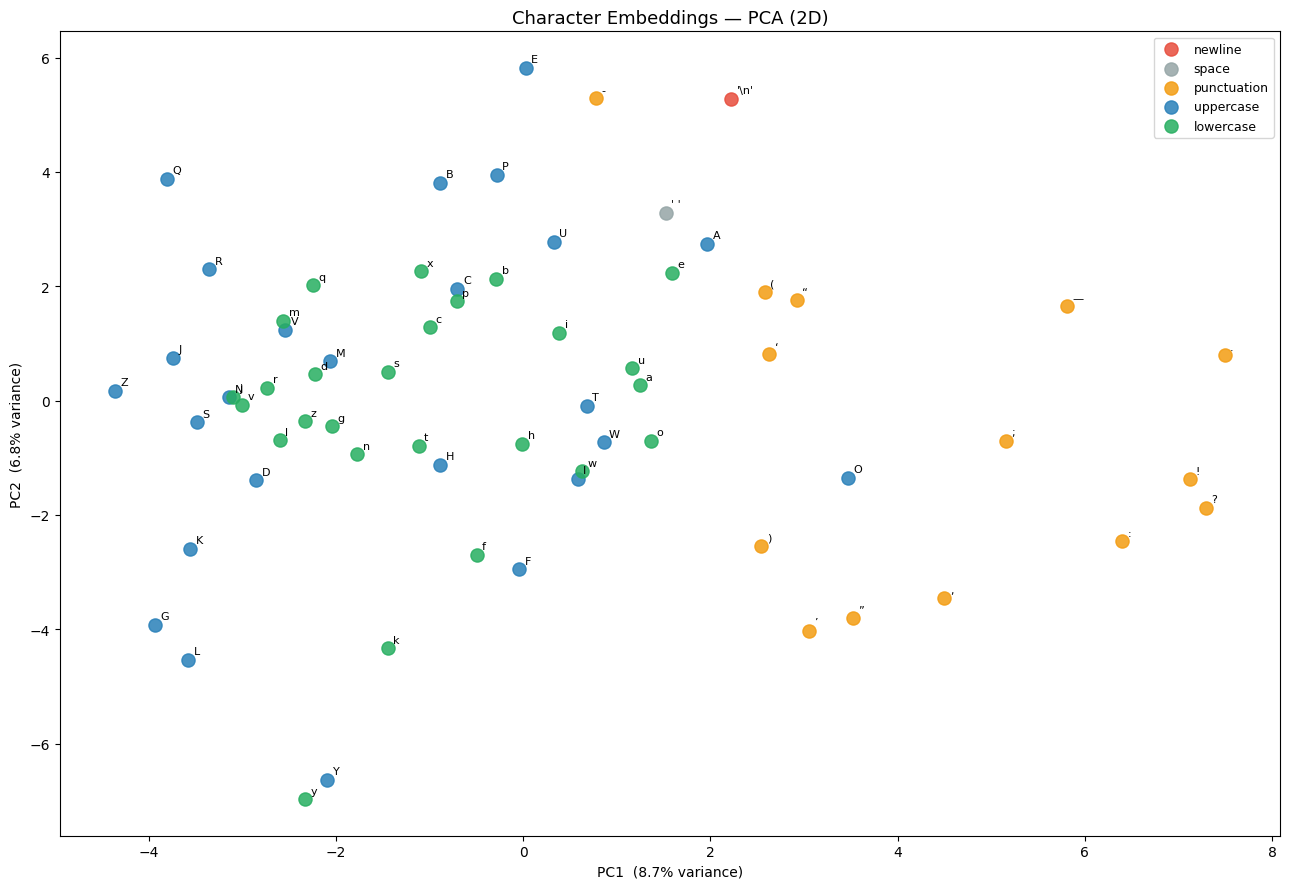

In [11]:
from sklearn.decomposition import PCA

weights = model.embedding.weight.detach().cpu().numpy()  # (67, 64)

pca    = PCA(n_components=2)
coords = pca.fit_transform(weights)                       # (67, 2)

# Colour by character type
def char_color(ch):
    if ch == '\n':                                          return '#e74c3c', 'newline'
    if ch == ' ':                                           return '#95a5a6', 'space'
    if ch in '!(),-.:;?—\u2018\u2019\u201c\u201d':         return '#f39c12', 'punctuation'
    if ch.isupper():                                        return '#2980b9', 'uppercase'
    if ch.islower():                                        return '#27ae60', 'lowercase'
    return '#7f8c8d', 'other'

fig, ax = plt.subplots(figsize=(13, 9))

seen_labels = set()
for idx in range(VOCAB_SIZE):
    ch = idx_to_char[idx]
    color, label = char_color(ch)
    show_label = label not in seen_labels
    ax.scatter(*coords[idx], color=color, s=90, alpha=0.85,
               label=label if show_label else None)
    seen_labels.add(label)
    display = repr(ch) if ch in (' ', '\n') else ch
    ax.annotate(display, coords[idx], fontsize=8,
                xytext=(4, 4), textcoords='offset points')

ax.legend(loc='upper right', fontsize=9)
ax.set_title("Character Embeddings — PCA (2D)", fontsize=13)
ax.set_xlabel(f"PC1  ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2  ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.tight_layout()
plt.show()

## 2 — Attention Heatmaps

For a given phrase, we manually step through each transformer layer and call the self-attention module with `need_weights=True` to extract per-head attention weights.

Each heatmap is **T × T** (T = number of characters in the phrase):
- **Row** = query position (the character being predicted *from*)
- **Column** = key position (what it's attending *to*)

The causal mask means the upper triangle is always zero — position `i` cannot see position `j > i`.

Things to look for:
- Does any head specialize in tracking **spaces** (word boundaries)?
- Does any head focus on **recent characters** (diagonal) vs **distant context**?
- Do heads differ meaningfully between layer 1 and layer 2?

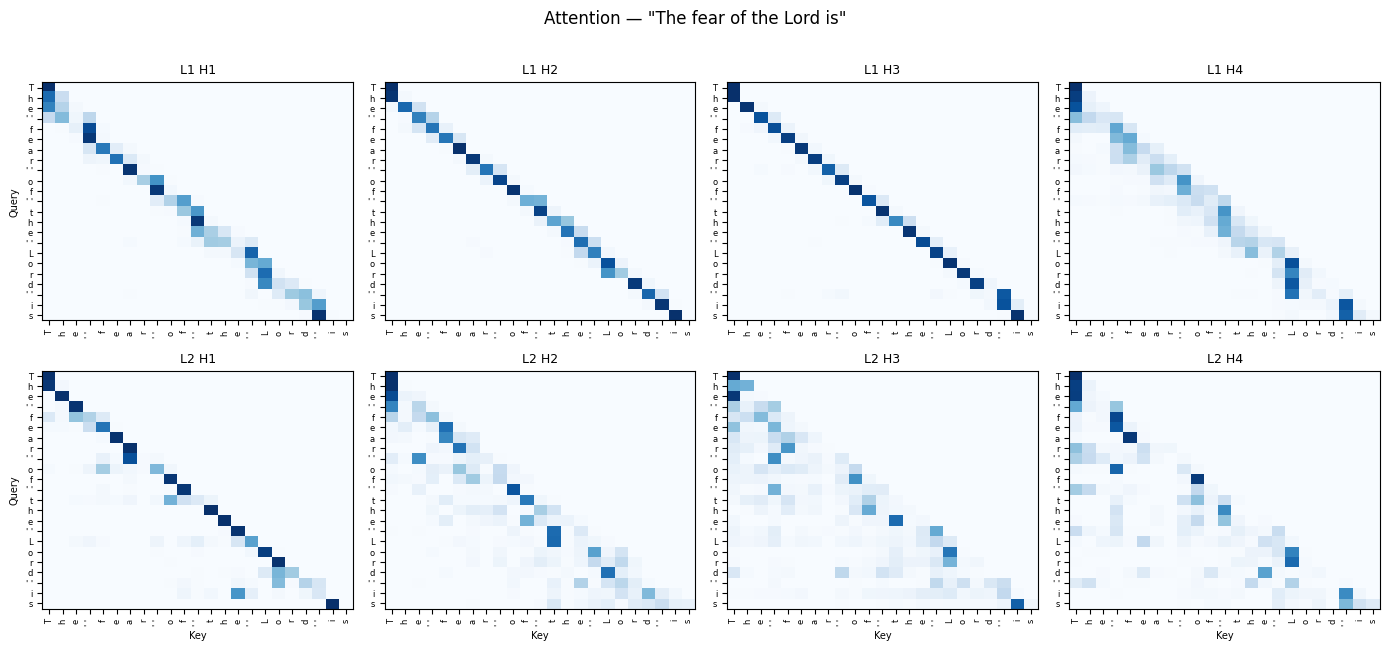

In [9]:
def get_attention_weights(phrase: str):
    """
    Forward-pass `phrase` through the transformer and return per-layer,
    per-head attention weight matrices.

    Returns:
        layer_weights : list of np.ndarray, each (n_heads, T, T)
        chars         : list of characters that made it into the vocab
    """
    chars  = [ch for ch in phrase if ch in char_to_idx]
    tokens = torch.tensor([char_to_idx[ch] for ch in chars],
                          dtype=torch.long).unsqueeze(0)   # (1, T)
    T = tokens.shape[1]

    with torch.no_grad():
        positions = torch.arange(T)
        x = model.embedding(tokens) + model.pos_embedding(positions)  # (1, T, E)

        causal_mask = torch.triu(torch.ones(T, T), diagonal=1).bool()

        layer_weights = []
        for layer in model.transformer.layers:
            # Call self-attention directly to get per-head weights
            attn_out, attn_w = layer.self_attn(
                x, x, x,
                attn_mask=causal_mask,
                need_weights=True,
                average_attn_weights=False,   # shape: (1, n_heads, T, T)
            )
            layer_weights.append(attn_w.squeeze(0).cpu().numpy())  # (n_heads, T, T)

            # Continue through the rest of the layer (dropout is identity in eval mode)
            x = layer.norm1(x + attn_out)
            ff = layer.linear2(layer.activation(layer.linear1(x)))
            x = layer.norm2(x + ff)

    return layer_weights, chars


def plot_attention(phrase: str):
    layer_weights, chars = get_attention_weights(phrase)
    n_layers = len(layer_weights)
    n_heads  = layer_weights[0].shape[0]
    T        = len(chars)

    fig, axes = plt.subplots(
        n_layers, n_heads,
        figsize=(3.5 * n_heads, 3.2 * n_layers),
        squeeze=False,
    )
    fig.suptitle(f'Attention — "{phrase}"', fontsize=12, y=1.01)

    for l, weights in enumerate(layer_weights):
        for h in range(n_heads):
            ax = axes[l][h]
            w  = weights[h]          # (T, T)

            im = ax.imshow(w, aspect='auto', cmap='Blues', vmin=0, vmax=w.max())

            ax.set_xticks(range(T))
            ax.set_yticks(range(T))
            tick_labels = [repr(c) if c == ' ' else c for c in chars]
            ax.set_xticklabels(tick_labels, fontsize=6, rotation=90)
            ax.set_yticklabels(tick_labels, fontsize=6)
            ax.set_title(f"L{l+1} H{h+1}", fontsize=9)

            if h == 0:
                ax.set_ylabel("Query", fontsize=7)
            if l == n_layers - 1:
                ax.set_xlabel("Key", fontsize=7)

    plt.tight_layout()
    plt.show()


# ── Run it ────────────────────────────────────────────────────────────────────
plot_attention("The fear of the Lord is")

## Try other phrases

Swap in any string from the corpus — or a generated phrase — to see how attention shifts.

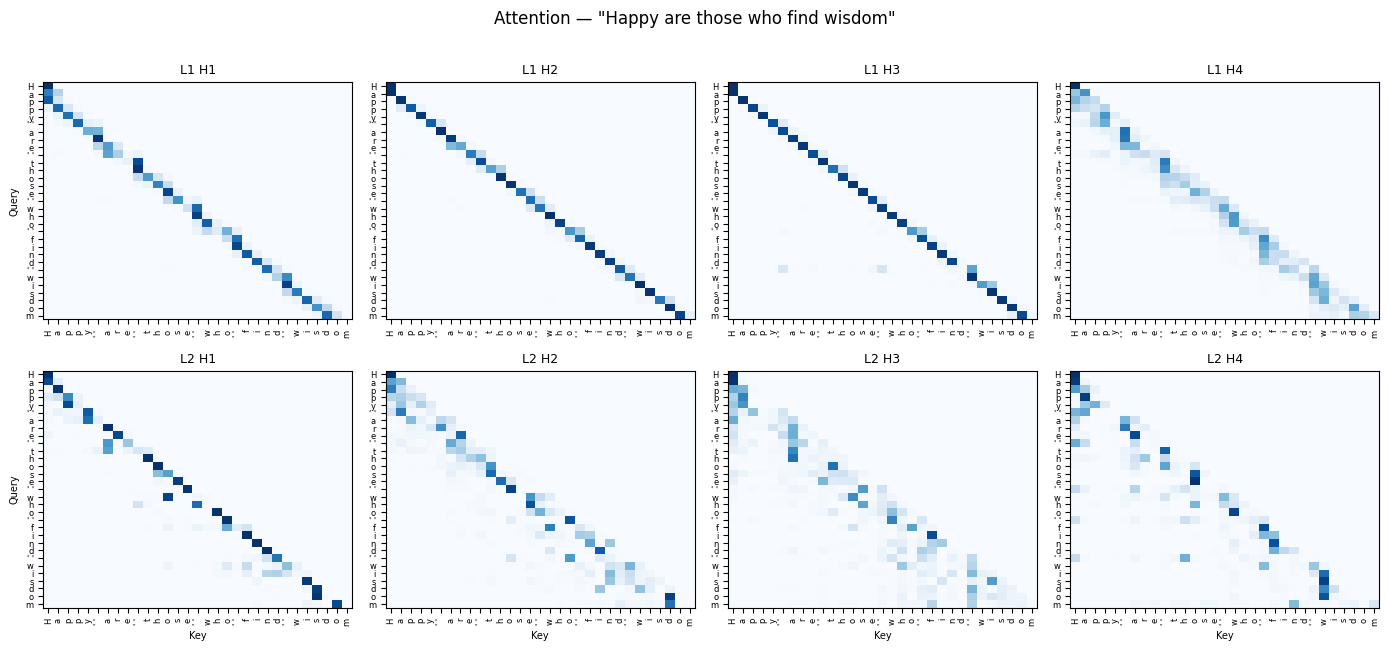

In [10]:
plot_attention("Happy are those who find wisdom")